## Importación de librerías esenciales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

## Carga de los Datasets

In [2]:
df_energy = pd.read_csv('datos/energy_dataset.csv')
df_weather = pd.read_csv('datos/weather_features.csv')

print(f"Dataset Energía: {df_energy.shape[0]} filas, {df_energy.shape[1]} columnas.")
print(f"Dataset Clima: {df_weather.shape[0]} filas, {df_weather.shape[1]} columnas.")

Dataset Energía: 35064 filas, 29 columnas.
Dataset Clima: 178396 filas, 17 columnas.


## Preprocesamiento y Agregación Horaria del Clima

In [3]:
# 1. Convertir la columna de tiempo al formato Datetime de Pandas y manejar zonas horarias
df_weather['dt_iso'] = pd.to_datetime(df_weather['dt_iso'], utc=True)

# 2. Convertir las variables de temperatura de Kelvin a Grados Celsius
temp_columns = ['temp', 'temp_min', 'temp_max']
for col in temp_columns:
    df_weather[col] = df_weather[col] - 273.15

# 3. Seleccionar las columnas meteorológicas clave justificadas en tus Objetivos del TFM
columns_to_keep = ['dt_iso', 'temp', 'humidity', 'wind_speed']
df_weather_filtered = df_weather[columns_to_keep]

# 4. Agrupar por hora (dt_iso) calculando la media de todas las ciudades para tener el promedio del país
df_weather_hourly = df_weather_filtered.groupby('dt_iso').mean().reset_index()

print(f"Dataset de clima procesado y unificado: {df_weather_hourly.shape[0]} horas únicas.")
df_weather_hourly.head()

Dataset de clima procesado y unificado: 35064 horas únicas.


,dt_iso,temp,humidity,wind_speed
0,2014-12-31 23:00:00+00:00,-0.658537,82.4,2.0
1,2015-01-01 00:00:00+00:00,-0.637300,82.4,2.0
2,2015-01-01 01:00:00+00:00,-1.050862,82.0,2.4
3,2015-01-01 02:00:00+00:00,-1.060531,82.0,2.4
4,2015-01-01 03:00:00+00:00,-1.004100,82.0,2.4


## Preparación del Dataset de Energía y Fusión (Merge)

In [4]:
# 1. Convertir la columna de tiempo al formato Datetime (UTC) para que coincida con el clima
df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True)

# 2. Seleccionar la variable objetivo (carga real) y el tiempo
df_energy_filtered = df_energy[['time', 'total load actual']]

# 3. Fusionar ambos datasets usando el eje temporal común
df_master = pd.merge(df_energy_filtered, df_weather_hourly, left_on='time', right_on='dt_iso', how='inner')

# Eliminar columna duplicada de tiempo y establecerla como índice del DataFrame
df_master = df_master.drop(columns=['dt_iso'])
df_master = df_master.set_index('time')

print(f"Dataset definitivo listo: {df_master.shape[0]} filas y {df_master.shape[1]} columnas.")
df_master.head()

Dataset definitivo listo: 35064 filas y 4 columnas.


,total load actual,temp,humidity,wind_speed
time,,,,
2014-12-31 23:00:00+00:00,25385.0,-0.658537,82.4,2.0
2015-01-01 00:00:00+00:00,24382.0,-0.637300,82.4,2.0
2015-01-01 01:00:00+00:00,22734.0,-1.050862,82.0,2.4
2015-01-01 02:00:00+00:00,21286.0,-1.060531,82.0,2.4
2015-01-01 03:00:00+00:00,20264.0,-1.004100,82.0,2.4


## Control de Calidad de Datos (Tratamiento de Nulos)

In [5]:
# Verificar si quedan valores nulos en el dataset unificado
null_counts = df_master.isnull().sum()
print("Valores nulos detectados por columna antes de la limpieza:")
print(null_counts)

# Si existen nulos en la variable objetivo 'total_load_actual', aplicamos interpolación lineal 
# para no romper la secuencia temporal para la red LSTM
if df_master['total load actual'].isnull().sum() > 0:
    df_master['total load actual'] = df_master['total load actual'].interpolate(method='linear')

print("\nConteo de nulos finalizado con éxito:")
print(df_master.isnull().sum())

Valores nulos detectados por columna antes de la limpieza:
total load actual    36
temp                  0
humidity              0
wind_speed            0
dtype: int64

Conteo de nulos finalizado con éxito:
total load actual    0
temp                 0
humidity             0
wind_speed           0
dtype: int64


## Análisis Exploratorio Rápido

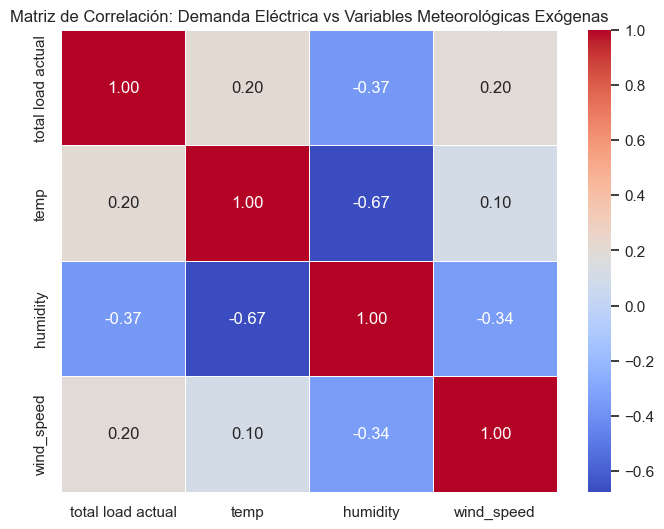

In [6]:
plt.figure(figsize=(8, 6))
correlation_matrix = df_master.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Demanda Eléctrica vs Variables Meteorológicas Exógenas')

plt.show()

## Guardar el Dataset Maestro Limpio

In [7]:
# Exportar a un archivo CSV limpio que se utilizara para entrenar la red LSTM
df_master.to_csv('datos/dataset_energia_clima_limpio.csv')

## Preparación de Ventanas Temporales y Escalado

In [8]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.optimizers import Adam

# 1. Separación de características para ambos enfoques
features_uni = ['total load actual']
features_multi = ['total load actual', 'temp', 'humidity', 'wind_speed']

# Escalamos los datos entre 0 y 1
scaler_uni = MinMaxScaler()
scaler_multi = MinMaxScaler()

scaled_uni = scaler_uni.fit_transform(df_master[features_uni])
scaled_multi = scaler_multi.fit_transform(df_master[features_multi])

# 2. Función para crear las estructuras de secuencias temporales (Ventanas de 24 horas)
def create_dataset(dataset, look_back=24):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0]) # La variable objetivo siempre es la carga (columna 0)
    return np.array(X), np.array(Y)

# Definimos la ventana temporal: usar las últimas 24 horas para predecir la hora 25
look_back = 24

X_uni, y_uni = create_dataset(scaled_uni, look_back)
X_multi, y_multi = create_dataset(scaled_multi, look_back)

# 3. División Cronológica (80% Entrenamiento, 20% Prueba / Test)
train_size = int(len(X_uni) * 0.80)

X_train_uni, X_test_uni = X_uni[:train_size], X_uni[train_size:]
y_train_uni, y_test_uni = y_uni[:train_size], y_uni[train_size:]

X_train_multi, X_test_multi = X_multi[:train_size], X_multi[train_size:]
y_train_multi, y_test_multi = y_multi[:train_size], y_multi[train_size:]

print(f"Datos Univariantes - Entrenamiento: {X_train_uni.shape}, Prueba: {X_test_uni.shape}")
print(f"Datos Multivariantes - Entrenamiento: {X_train_multi.shape}, Prueba: {X_test_multi.shape}")

c:\Users\josed\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Datos Univariantes - Entrenamiento: (28032, 24, 1), Prueba: (7008, 24, 1)
Datos Multivariantes - Entrenamiento: (28032, 24, 4), Prueba: (7008, 24, 4)


## Entrenamiento del Modelo A (LSTM Univariante - Solo Histórico)

In [9]:
model_uni = Sequential([
    Input(shape=(look_back, 1)),
    LSTM(50, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model_uni.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Entrenar la red
history_uni = model_uni.fit(
    X_train_uni, y_train_uni, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1
)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0249 - val_loss: 0.0093
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0085 - val_loss: 0.0053
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0063 - val_loss: 0.0035
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0051 - val_loss: 0.0029
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0043 - val_loss: 0.0021
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0036 - val_loss: 0.0025
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0032 - val_loss: 0.0014
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0029 - val_loss: 0.0013
Epoch 9/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0027 - val_loss: 0.0013
Epoch 10/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0025 - val_loss: 0.0013


## Entrenamiento del Modelo B (LSTM Multivariante - Propuesta con Clima)

In [10]:
model_multi = Sequential([
    # input_shape recibe (24 horas, 4 variables)
    Input(shape=(look_back, 4)),
    LSTM(50, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model_multi.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Entrenar la red
history_multi = model_multi.fit(
    X_train_multi, y_train_multi, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1
)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0260 - val_loss: 0.0109
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0081 - val_loss: 0.0037
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0052 - val_loss: 0.0029
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0042 - val_loss: 0.0023
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0036 - val_loss: 0.0019
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0031 - val_loss: 0.0016
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0027 - val_loss: 0.0014
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0024 - val_loss: 0.0016
Epoch 9/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0022 - val_loss: 0.0012
Epoch 10/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0021 - val_loss: 0.0013


## Entrenamiento de modelos baseline

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Flatten the 24-hour lagged sequences for classical baseline models
X_train_baseline = X_train_multi.reshape(X_train_multi.shape[0], -1)
X_test_baseline = X_test_multi.reshape(X_test_multi.shape[0], -1)

y_train_baseline = y_train_multi
y_test_baseline = y_test_multi

# Linear Regression baseline
lr_baseline = LinearRegression()
lr_baseline.fit(X_train_baseline, y_train_baseline)
pred_lr_baseline = lr_baseline.predict(X_test_baseline)

# Random Forest baseline
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42)
rf_baseline.fit(X_train_baseline, y_train_baseline)
pred_rf_baseline = rf_baseline.predict(X_test_baseline)

# Convertimos a escala original para comparar con los LSTM
dummy_lr = np.zeros((len(pred_lr_baseline), 4))
dummy_lr[:, 0] = pred_lr_baseline.ravel()
pred_lr_baseline_real = scaler_multi.inverse_transform(dummy_lr)[:, 0]

dummy_rf = np.zeros((len(pred_rf_baseline), 4))
dummy_rf[:, 0] = pred_rf_baseline.ravel()
pred_rf_baseline_real = scaler_multi.inverse_transform(dummy_rf)[:, 0]

dummy_y_test = np.zeros((len(y_test_baseline), 4))
dummy_y_test[:, 0] = y_test_baseline.ravel()
y_test_baseline_real = scaler_multi.inverse_transform(dummy_y_test)[:, 0]

print("Modelos baseline entrenados correctamente sobre el conjunto multivariante.")

Modelos baseline entrenados correctamente sobre el conjunto multivariante.


## Extracción de Métricas Reales (MAE, RMSE, MAPE)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 1. Predicciones y des-escalado para el Modelo Univariante
pred_uni_scaled = model_uni.predict(X_test_uni)
pred_uni = scaler_uni.inverse_transform(pred_uni_scaled).flatten()
y_test_uni_real = scaler_uni.inverse_transform(y_test_uni.reshape(-1, 1)).flatten()

# 2. Predicciones y des-escalado para el Modelo Multivariante
pred_multi_scaled = model_multi.predict(X_test_multi)
dummy_matrix = np.zeros((len(pred_multi_scaled), 4))
dummy_matrix[:, 0] = pred_multi_scaled.flatten()
pred_multi = scaler_multi.inverse_transform(dummy_matrix)[:, 0]

# 3. Métricas para los modelos baseline
mae_lr_baseline = mean_absolute_error(y_test_baseline_real, pred_lr_baseline_real)
rmse_lr_baseline = np.sqrt(mean_squared_error(y_test_baseline_real, pred_lr_baseline_real))
mape_lr_baseline = calculate_mape(y_test_baseline_real, pred_lr_baseline_real)

mae_rf_baseline = mean_absolute_error(y_test_baseline_real, pred_rf_baseline_real)
rmse_rf_baseline = np.sqrt(mean_squared_error(y_test_baseline_real, pred_rf_baseline_real))
mape_rf_baseline = calculate_mape(y_test_baseline_real, pred_rf_baseline_real)

# --- Métricas LSTM ---
mae_uni = mean_absolute_error(y_test_uni_real, pred_uni)
rmse_uni = np.sqrt(mean_squared_error(y_test_uni_real, pred_uni))
mape_uni = calculate_mape(y_test_uni_real, pred_uni)

mae_multi = mean_absolute_error(y_test_uni_real, pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_uni_real, pred_multi))
mape_multi = calculate_mape(y_test_uni_real, pred_multi)

# Comparativa en tabla
metrics_table = pd.DataFrame([
    {'Modelo': 'Baseline LR', 'MAE (MW)': mae_lr_baseline, 'RMSE (MW)': rmse_lr_baseline, 'MAPE (%)': mape_lr_baseline},
    {'Modelo': 'Baseline RF', 'MAE (MW)': mae_rf_baseline, 'RMSE (MW)': rmse_rf_baseline, 'MAPE (%)': mape_rf_baseline},
    {'Modelo': 'LSTM Univariante', 'MAE (MW)': mae_uni, 'RMSE (MW)': rmse_uni, 'MAPE (%)': mape_uni},
    {'Modelo': 'LSTM Multivariante', 'MAE (MW)': mae_multi, 'RMSE (MW)': rmse_multi, 'MAPE (%)': mape_multi}
])
metrics_table[['MAE (MW)', 'RMSE (MW)', 'MAPE (%)']] = metrics_table[['MAE (MW)', 'RMSE (MW)', 'MAPE (%)']].round(2)

print("\n" + "="*60)
print("TABLA FINAL DE MÉTRICAS")
print("="*60)
print(metrics_table.to_string(index=False))
print("="*60)

219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

TABLA FINAL DE MÉTRICAS
            Modelo  MAE (MW)  RMSE (MW)  MAPE (%)
       Baseline LR    485.26     737.62      1.72
       Baseline RF    302.33     518.86      1.05
  LSTM Univariante    549.33     759.00      1.92
LSTM Multivariante    574.76     778.47      2.02


## Comparación global entre modelos Baseline y LSTM

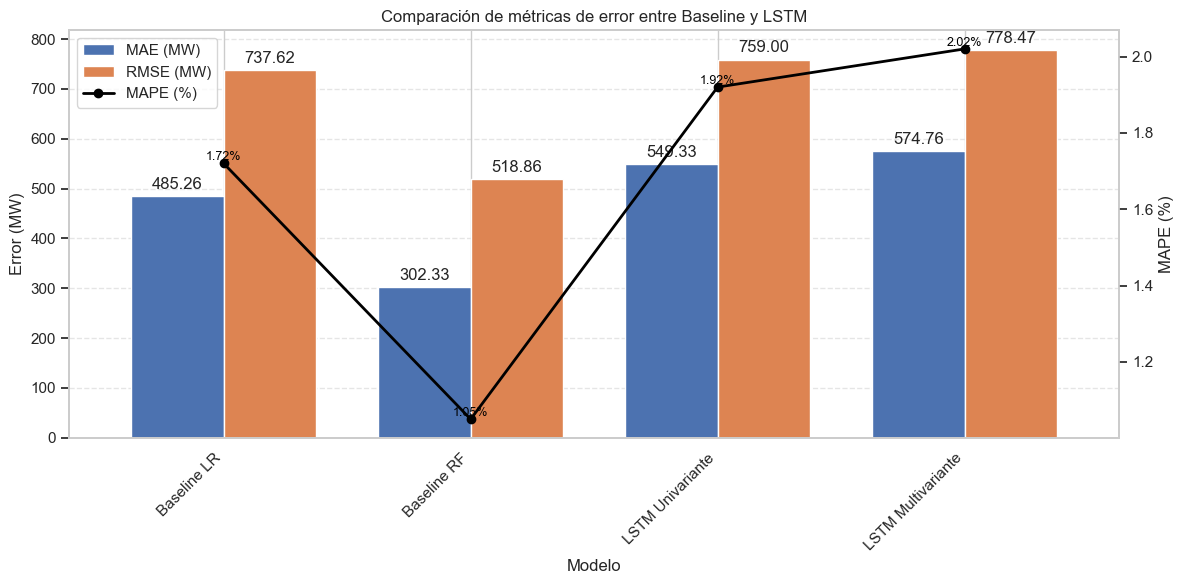

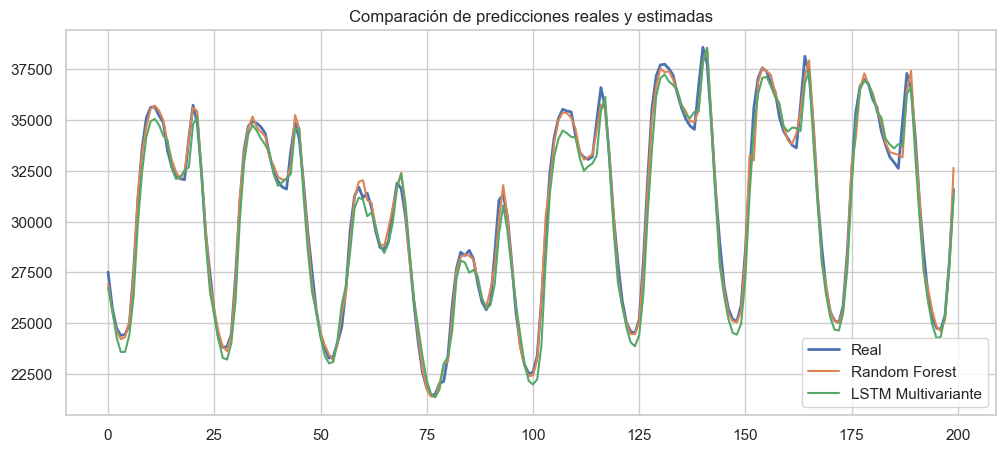

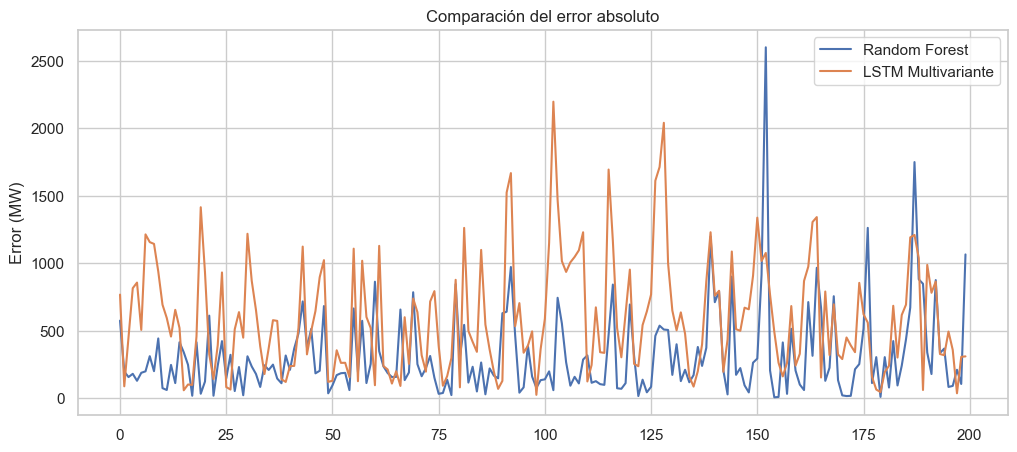

In [13]:
# Representación comparativa de las métricas de error
metrics_plot = metrics_table.set_index('Modelo')[["MAE (MW)", "RMSE (MW)"]]

fig, ax = plt.subplots(figsize=(12, 6))
metrics_plot.plot(kind='bar', ax=ax, width=0.75)

ax2 = ax.twinx()
mape_series = metrics_table.set_index('Modelo')["MAPE (%)"]
x_positions = np.arange(len(mape_series))
line_mape, = ax2.plot(
    x_positions,
    mape_series.values,
    marker='o',
    color='black',
    linewidth=2,
    label='MAPE (%)'
)

ax.set_title('Comparación de métricas de error entre Baseline y LSTM')
ax.set_ylabel('Error (MW)')
ax2.set_ylabel('MAPE (%)')
ax.set_xlabel('Modelo')
ax.set_xticks(x_positions)
ax.set_xticklabels(mape_series.index, rotation=45, ha='right')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines + [line_mape], labels + ['MAPE (%)'], loc='upper left')

# Unificar líneas de cuadrícula y evitar grid en el eje secundario
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax2.grid(False)

# Añadir etiquetas de valor a las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

# Añadir etiquetas en los puntos de la línea MAPE
for x, y in zip(x_positions, mape_series.values):
    ax2.text(x, y, f'{y:.2f}%', color='black', fontsize=9, ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Comparación de predicciones reales y estimadas
plt.figure(figsize=(12,5))

plt.plot(
    y_test_baseline_real[:200],
    label="Real",
    linewidth=2
)

plt.plot(
    pred_rf_baseline_real[:200],
    label="Random Forest"
)

plt.plot(
    pred_multi[:200],
    label="LSTM Multivariante"
)

plt.legend()
plt.title("Comparación de predicciones reales y estimadas")
plt.show()

error_rf = np.abs(
    y_test_baseline_real - pred_rf_baseline_real
)

error_lstm = np.abs(
    y_test_baseline_real - pred_multi
)

plt.figure(figsize=(12,5))

plt.plot(
    error_rf[:200],
    label="Random Forest"
)

plt.plot(
    error_lstm[:200],
    label="LSTM Multivariante"
)

plt.title("Comparación del error absoluto")
plt.ylabel("Error (MW)")
plt.legend()

plt.show()

## Análisis Exploratorio de Datos Avanzado (EDA Extendido)

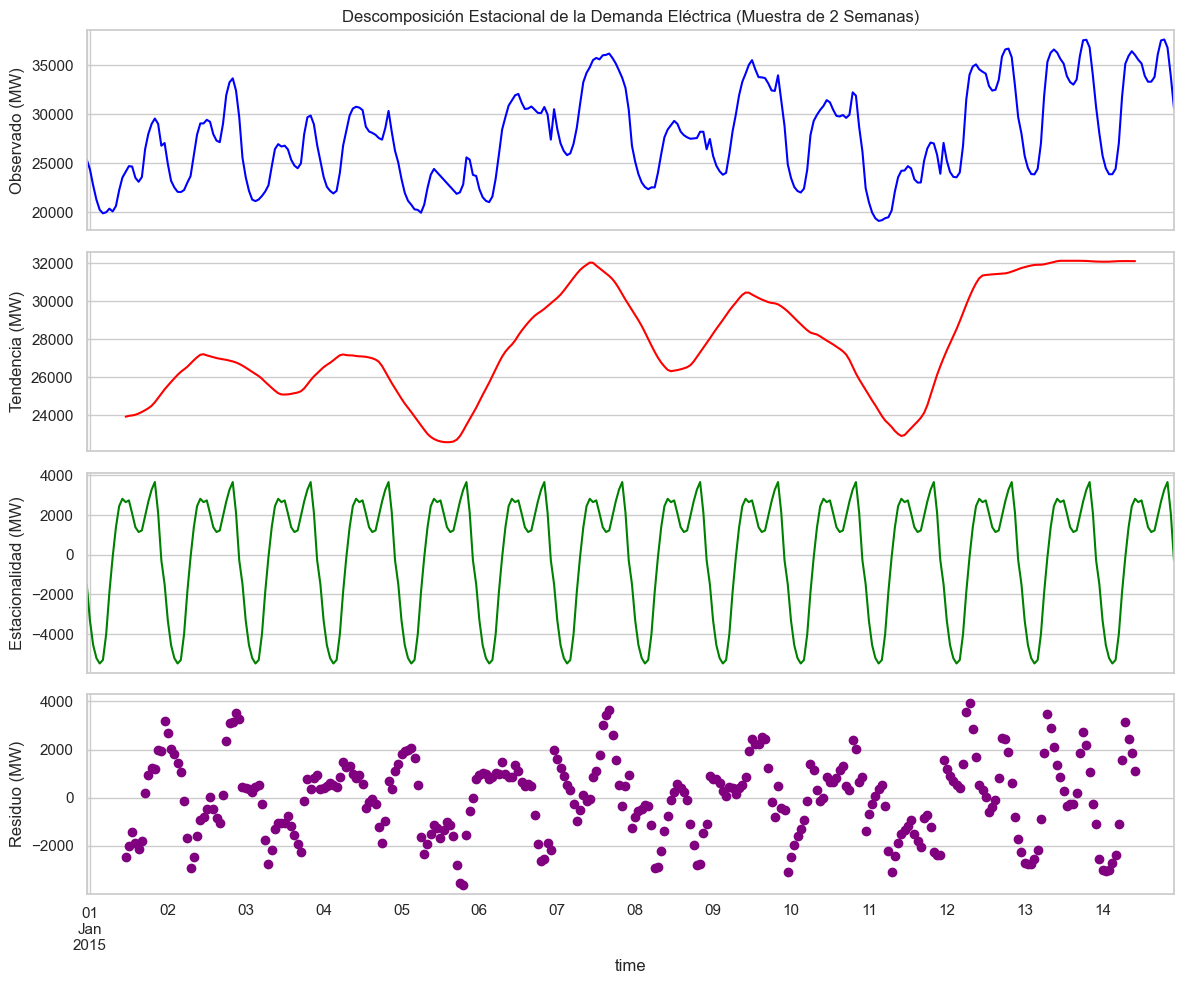

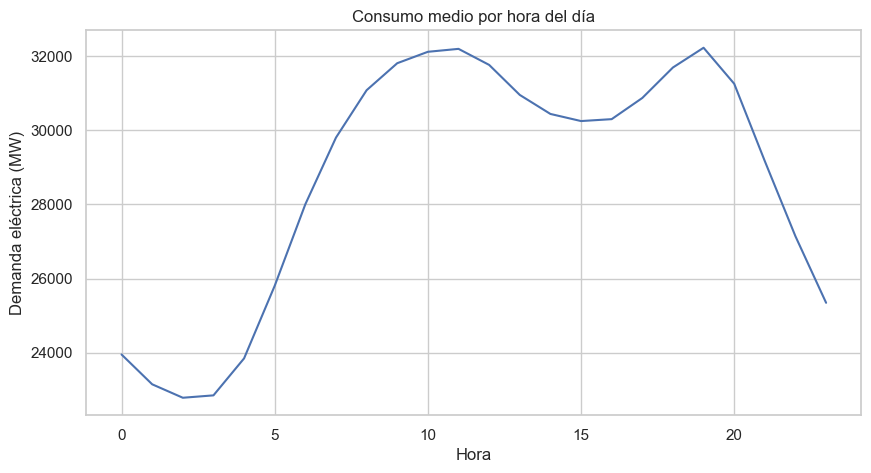

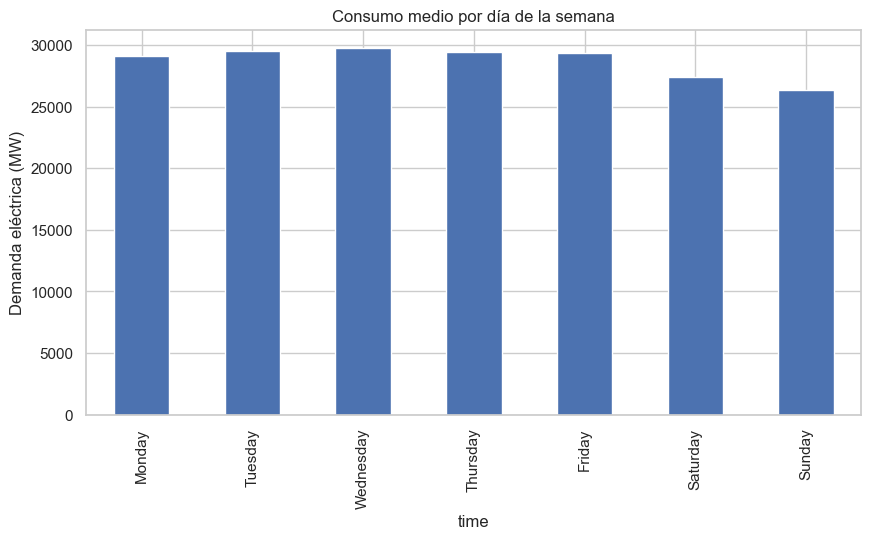

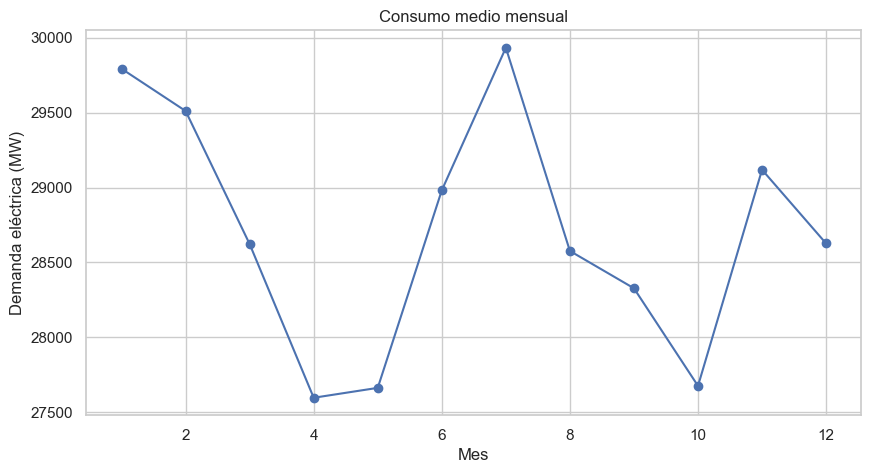

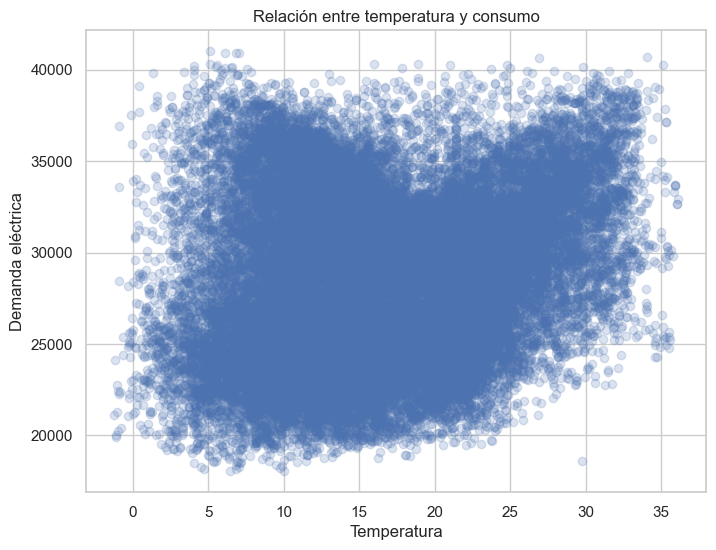

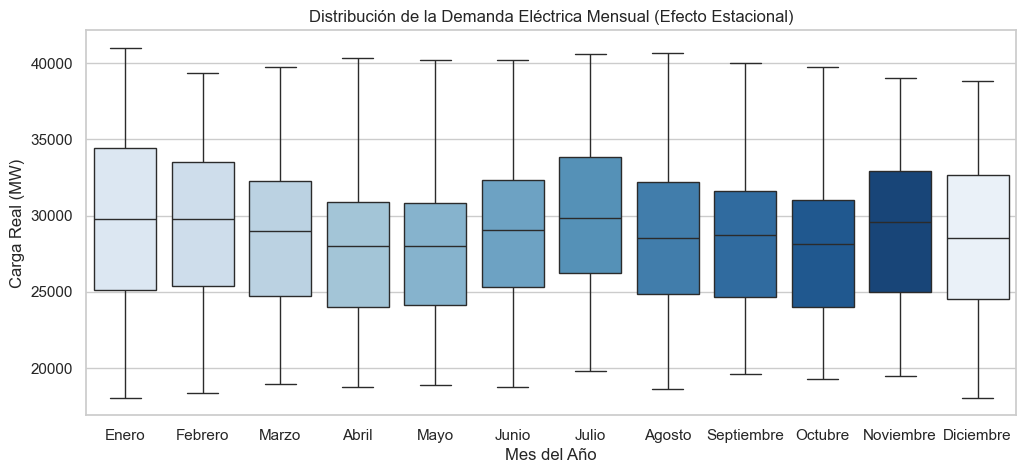

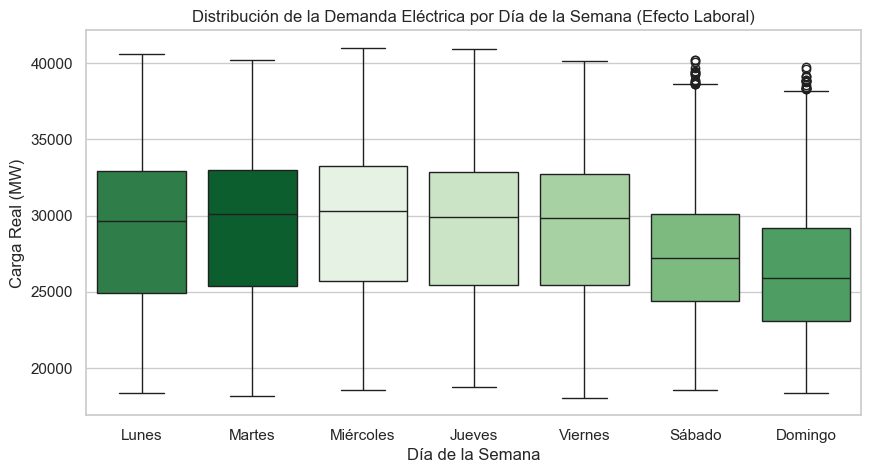

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Volvemos a cargar el índice sin zona horaria temporal para evitar conflictos en statsmodels
df_eda = pd.read_csv('datos/dataset_energia_clima_limpio.csv', parse_dates=['time'], index_col=False)
df_eda = df_eda.set_index('time')

# Tomamos una muestra de las primeras 2 semanas (336 horas) para que el gráfico sea legible en la memoria
sample_load = df_eda['total load actual'].iloc[:336]
result = seasonal_decompose(sample_load, model='additive', period=24)

# Graficar la descomposición estacional en formato académico
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
result.observed.plot(ax=ax1, color='blue')
ax1.set_ylabel('Observado (MW)')
ax1.set_title('Descomposición Estacional de la Demanda Eléctrica (Muestra de 2 Semanas)')

result.trend.plot(ax=ax2, color='red')
ax2.set_ylabel('Tendencia (MW)')

result.seasonal.plot(ax=ax3, color='green')
ax3.set_ylabel('Estacionalidad (MW)')

result.resid.plot(ax=ax4, color='purple', style='o')
ax4.set_ylabel('Residuo (MW)')

plt.tight_layout()
plt.show()

# Consumo medio por hora
hourly_profile = df_eda.groupby(df_eda.index.hour)["total load actual"].mean()

plt.figure(figsize=(10,5))
hourly_profile.plot()
plt.title("Consumo medio por hora del día")
plt.xlabel("Hora")
plt.ylabel("Demanda eléctrica (MW)")
plt.grid(True)
plt.show()

daily_profile = df_eda.groupby(df_eda.index.day_name())["total load actual"].mean()

orden = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_profile = daily_profile.reindex(orden)

plt.figure(figsize=(10,5))
daily_profile.plot(kind="bar")
plt.title("Consumo medio por día de la semana")
plt.ylabel("Demanda eléctrica (MW)")
plt.show()

monthly_profile = df_eda.groupby(df_eda.index.month)["total load actual"].mean()

plt.figure(figsize=(10,5))
monthly_profile.plot(marker="o")
plt.title("Consumo medio mensual")
plt.xlabel("Mes")
plt.ylabel("Demanda eléctrica (MW)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(
    df_eda["temp"],
    df_eda["total load actual"],
    alpha=0.2
)

plt.xlabel("Temperatura")
plt.ylabel("Demanda eléctrica")
plt.title("Relación entre temperatura y consumo")
plt.show()

# Extraer características temporales
df_eda['Mes'] = df_eda.index.month
df_eda['Dia_Semana'] = df_eda.index.dayofweek # 0=Lunes, 6=Domingo

# Cambiar índices numéricos a nombres textuales para el formato APA del TFM
meses_nombres = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril', 5:'Mayo', 6:'Junio', 
                 7:'Julio', 8:'Agosto', 9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'}
dias_nombres = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes', 5:'Sábado', 6:'Domingo'}

df_eda['Nombre_Mes'] = df_eda['Mes'].map(meses_nombres)
df_eda['Nombre_Dia'] = df_eda['Dia_Semana'].map(dias_nombres)

# Gráfico A: Distribución de Carga por Mes
plt.figure(figsize=(12, 5))
sns.boxplot(x='Nombre_Mes', y='total load actual', data=df_eda, 
            order=['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre'],
            hue='Nombre_Mes', palette='Blues', legend=False)
plt.title('Distribución de la Demanda Eléctrica Mensual (Efecto Estacional)')
plt.xlabel('Mes del Año')
plt.ylabel('Carga Real (MW)')
plt.show()

# Gráfico B: Distribución de Carga por Día de la Semana
plt.figure(figsize=(10, 5))
sns.boxplot(x='Nombre_Dia', y='total load actual', data=df_eda, 
            order=['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo'],
            hue='Nombre_Dia', palette='Greens', legend=False)
plt.title('Distribución de la Demanda Eléctrica por Día de la Semana (Efecto Laboral)')
plt.xlabel('Día de la Semana')
plt.ylabel('Carga Real (MW)')
plt.show()

## Inclusión de Métricas de Pérdida (Learning Curves)

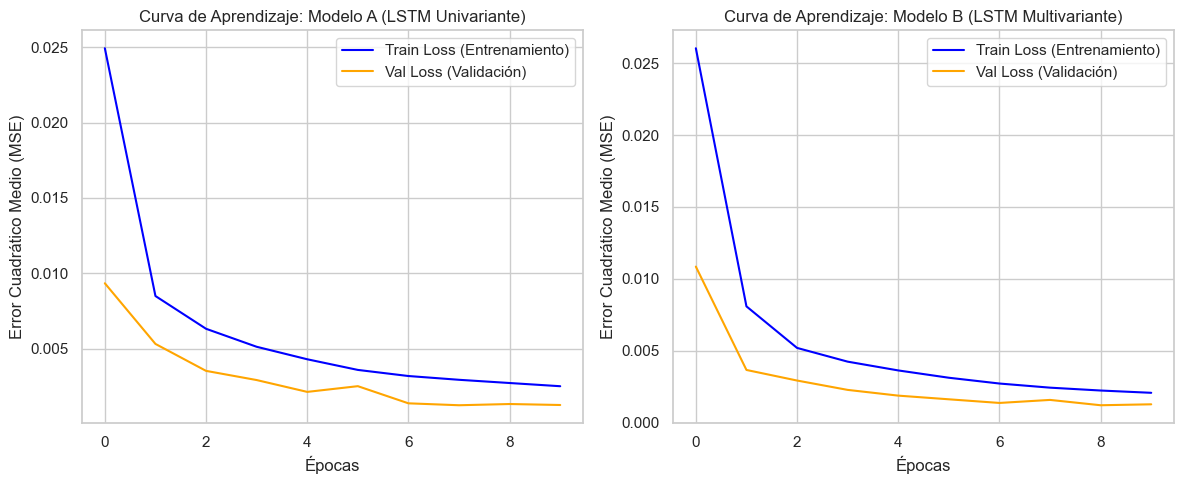

In [15]:
# Graficar curvas de aprendizaje para el Modelo A (Univariante)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_uni.history['loss'], label='Train Loss (Entrenamiento)', color='blue')
plt.plot(history_uni.history['val_loss'], label='Val Loss (Validación)', color='orange')
plt.title('Curva de Aprendizaje: Modelo A (LSTM Univariante)')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()

# Graficar curvas de aprendizaje para el Modelo B (Multivariante)
plt.subplot(1, 2, 2)
plt.plot(history_multi.history['loss'], label='Train Loss (Entrenamiento)', color='blue')
plt.plot(history_multi.history['val_loss'], label='Val Loss (Validación)', color='orange')
plt.title('Curva de Aprendizaje: Modelo B (LSTM Multivariante)')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()

plt.tight_layout()
plt.show()

## Optimización de Hiperparámetros (Hyperparameter Tuning)

In [16]:
from keras.optimizers import RMSprop

# Definimos el espacio de búsqueda de hiperparámetros
param_neurons = [32, 50]
param_dropouts = [0.1, 0.2]
param_optimizers = ['adam', 'rmsprop']

tuning_results = []

for neurons in param_neurons:
    for dropout_rate in param_dropouts:
        for opt_name in param_optimizers:
            print(f"Evaluando Configuración -> Neuronas: {neurons} | Dropout: {dropout_rate} | Optimizador: {opt_name}")
            
            # Construir el modelo dinámicamente
            model_tune = Sequential([
                Input(shape=(look_back, 4)),
                LSTM(neurons, activation='relu', return_sequences=False),
                Dropout(dropout_rate),
                Dense(1)
            ])
            
            # Asignar el optimizador correspondiente
            optimizer = Adam(learning_rate=0.001) if opt_name == 'adam' else RMSprop(learning_rate=0.001)
            model_tune.compile(optimizer=optimizer, loss='mse')
            
            # Entrenar de forma rápida (3 épocas para el experimento de sintonización)
            model_tune.fit(X_train_multi, y_train_multi, epochs=3, batch_size=128, verbose=0)
            
            # Evaluar sobre el conjunto de prueba (Test)
            pred_tune_scaled = model_tune.predict(X_test_multi, verbose=0)
            dummy_matrix_tune = np.zeros((len(pred_tune_scaled), 4))
            dummy_matrix_tune[:, 0] = pred_tune_scaled.flatten()
            pred_tune = scaler_multi.inverse_transform(dummy_matrix_tune)[:, 0]
            
            # Calcular MAE para esta combinación
            mae_tune = mean_absolute_error(y_test_uni_real, pred_tune)
            
            # Guardar el registro numérico
            tuning_results.append({
                'Neuronas': neurons,
                'Dropout': dropout_rate,
                'Optimizador': opt_name,
                'MAE_Resultante_MW': round(mae_tune, 2)
            })

# Convertir los resultados en una tabla estructurada
df_tuning = pd.DataFrame(tuning_results) 
df_tuning.to_csv('datos/resultados_optimizacion_hiperparametros.csv', index=False)

print("\n" + "="*60)
print("TABLA DE OPTIMIZACIÓN DE HIPERPARÁMETROS:")
print("="*60)
print(df_tuning.to_string(index=False))
print("="*60)

Evaluando Configuración -> Neuronas: 32 | Dropout: 0.1 | Optimizador: adam
Evaluando Configuración -> Neuronas: 32 | Dropout: 0.1 | Optimizador: rmsprop
Evaluando Configuración -> Neuronas: 32 | Dropout: 0.2 | Optimizador: adam
Evaluando Configuración -> Neuronas: 32 | Dropout: 0.2 | Optimizador: rmsprop
Evaluando Configuración -> Neuronas: 50 | Dropout: 0.1 | Optimizador: adam
Evaluando Configuración -> Neuronas: 50 | Dropout: 0.1 | Optimizador: rmsprop
Evaluando Configuración -> Neuronas: 50 | Dropout: 0.2 | Optimizador: adam
Evaluando Configuración -> Neuronas: 50 | Dropout: 0.2 | Optimizador: rmsprop

TABLA DE OPTIMIZACIÓN DE HIPERPARÁMETROS:
 Neuronas  Dropout Optimizador  MAE_Resultante_MW
       32      0.1        adam             926.01
       32      0.1     rmsprop             908.64
       32      0.2        adam             995.52
       32      0.2     rmsprop            1083.09
       50      0.1        adam             865.34
       50      0.1     rmsprop             94

## Importancia de Características (Feature Importance)

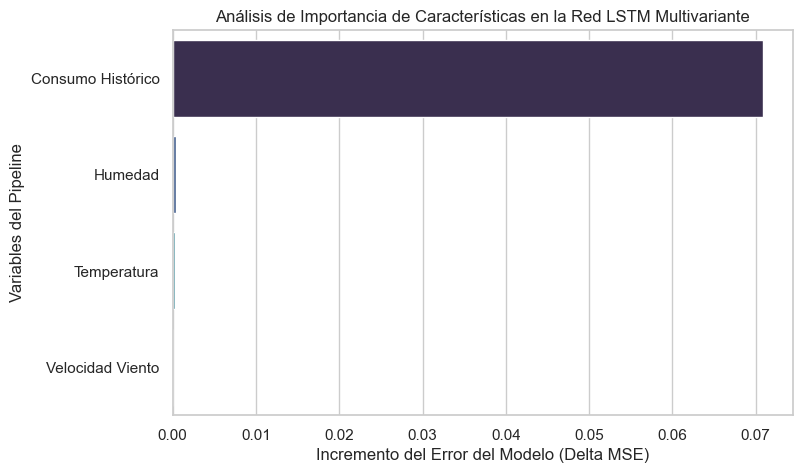


IMPORTANCIA DE LAS CARACTERÍSTICAS:
   Característica  Importancia (Delta MSE)
Consumo Histórico                 0.070918
          Humedad                 0.000427
      Temperatura                 0.000214
 Velocidad Viento                 0.000055


In [17]:
baseline_mse = model_multi.evaluate(X_test_multi, y_test_multi, verbose=0)
feature_importance = {}
feature_names = ['Consumo Histórico', 'Temperatura', 'Humedad', 'Velocidad Viento']

for i in range(4):
    X_test_permuted = X_test_multi.copy()
    # Permutar la característica a lo largo de todas las muestras y pasos de tiempo
    np.random.shuffle(X_test_permuted[:, :, i])
    
    permuted_mse = model_multi.evaluate(X_test_permuted, y_test_multi, verbose=0)
    # La importancia es el incremento en el error provocado por la permutación
    feature_importance[feature_names[i]] = permuted_mse - baseline_mse

# Crear DataFrame y Graficar
df_importance = pd.DataFrame({
    'Característica': feature_importance.keys(),
    'Importancia (Delta MSE)': feature_importance.values()
}).sort_values(by='Importancia (Delta MSE)', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importancia (Delta MSE)', y='Característica', data=df_importance, hue='Característica', palette='mako', legend=False)
plt.title('Análisis de Importancia de Características en la Red LSTM Multivariante')
plt.xlabel('Incremento del Error del Modelo (Delta MSE)')
plt.ylabel('Variables del Pipeline')
plt.show()

print("\n" + "="*50)
print("IMPORTANCIA DE LAS CARACTERÍSTICAS:")
print("="*50)
print(df_importance.to_string(index=False))
print("="*50)

## CSV para Power BI

In [18]:
dashboard_df = pd.DataFrame({
    'Fecha': df_master.index[-len(y_test_baseline_real):],
    'Demanda_Real': y_test_baseline_real,
    'Prediccion_RF': pred_rf_baseline_real,
    'Prediccion_LSTM': pred_multi,
    'Temperatura': df_master.iloc[-len(y_test_baseline_real):]['temp'].values,
    'Humedad': df_master.iloc[-len(y_test_baseline_real):]['humidity'].values,
    'Velocidad_Viento': df_master.iloc[-len(y_test_baseline_real):]['wind_speed'].values
})

dashboard_df['Fecha'] = pd.to_datetime(
    dashboard_df['Fecha']
).dt.tz_localize(None)

dashboard_df.to_csv("datos/dashboard_powerbi.csv", index=False)